# 02 - Temporal Exploratory Data Analysis (EDA)
## What this notebook does
This notebook quantifies the patterns between electricity prices and the temporal variables: hours, weeks, month, and year. For each variable, we examine the price formation.
## Key questions
- What is the distribution of day-ahead electricity price
- What is the temporal patterns of day-ahead electricity price

## Data 
Loaded from "data/processed/df_alls_cleaned.parquet" (produced by "01_data_processing.ipynb")

### Distribution of Prices

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)

In [14]:
df_alls = pd.read_parquet("../data/processed/df_alls_cleaned.parquet")

In [15]:
df_alls.head()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
timestamp,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00+01:00,01/01/2016 00:00:00 - 01/01/2016 01:00:00,BZN|FR,23.86,58639.0,58600.0,NaN,NaN,NaN,NaN,2313.42,NaN,NaN,2189.0,0.0,NaN,NaN,0.0
2016-01-01 01:00:00+01:00,01/01/2016 01:00:00 - 01/01/2016 02:00:00,BZN|FR,22.39,56733.0,56550.0,NaN,NaN,NaN,NaN,2003.04,NaN,NaN,1753.0,0.0,NaN,NaN,0.0
2016-01-01 02:00:00+01:00,01/01/2016 02:00:00 - 01/01/2016 03:00:00,BZN|FR,20.59,55127.0,56150.0,NaN,NaN,NaN,NaN,1743.72,NaN,NaN,1430.0,0.0,NaN,NaN,0.0
2016-01-01 03:00:00+01:00,01/01/2016 03:00:00 - 01/01/2016 04:00:00,BZN|FR,16.81,51744.0,52600.0,NaN,NaN,NaN,NaN,1490.09,NaN,NaN,1214.0,0.0,NaN,NaN,0.0
2016-01-01 04:00:00+01:00,01/01/2016 04:00:00 - 01/01/2016 05:00:00,BZN|FR,17.41,51744.0,49750.0,NaN,NaN,NaN,NaN,1238.09,NaN,NaN,1031.0,0.0,NaN,NaN,0.0


In [32]:
df_alls["Day-ahead Price (EUR/MWh)"].describe()

count    78912.000000
mean        82.573143
std         95.270461
min       -134.940000
25%         33.000000
50%         50.000000
75%         89.920000
max       2987.780000
Name: Day-ahead Price (EUR/MWh), dtype: float64

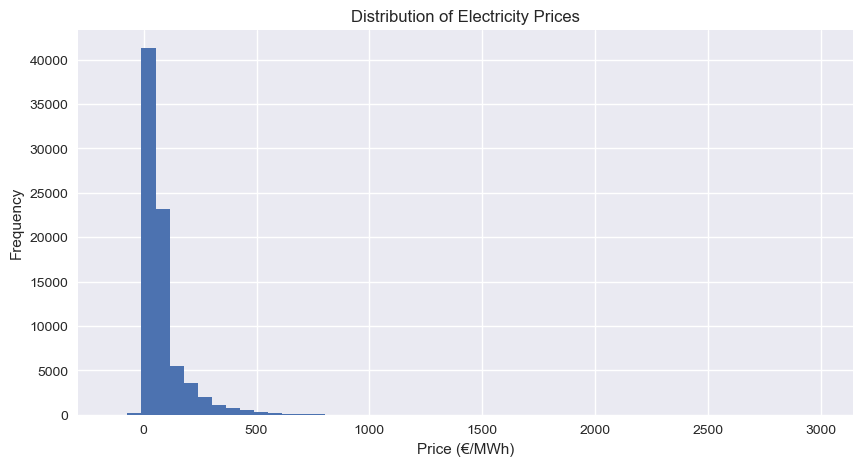

In [10]:
plt.figure(figsize = (10,5))
df_alls["Day-ahead Price (EUR/MWh)"].hist(bins=50)
plt.title("Distribution of Electricity Prices")
plt.xlabel("Price (€/MWh)")
plt.ylabel("Frequency")
plt.show()

Electricity prices show a right-skewed distribution. The price mean is 83 EUR/MWh, price median is 50 EUR/MWh, minimum price is -135 EUR/MWh. The maximum price 2988 EUR/MWh and its distance from the upper quantile indicates the occasional extreme price spikes. The extreme right-skewness will bias the modelling and careful handelling of error matrics. 

### Hourly Patterns

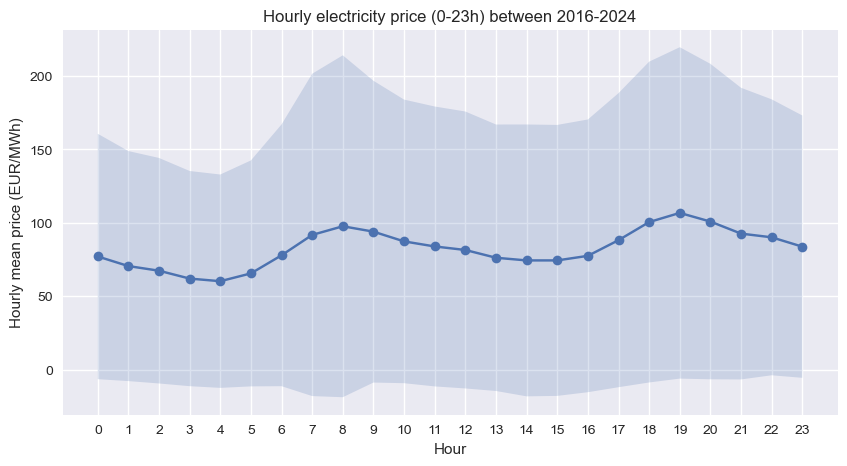

In [31]:
hourly_price = df_alls.groupby(df_alls.index.hour)["Day-ahead Price (EUR/MWh)"].agg(
    hourly_mean = "mean",
    hourly_std = "std"
)

plt.figure(figsize = (10,5))
plt.plot(hourly_price.index, hourly_price["hourly_mean"], marker = "o", label = "Mean")
plt.fill_between(hourly_price.index, 
                 hourly_price["hourly_mean"] - hourly_price["hourly_std"],
                 hourly_price["hourly_mean"] + hourly_price["hourly_std"],
                 alpha = 0.2, label = "±1 std")
plt.xticks(range(0, 24))
plt.xlabel("Hour")
plt.ylabel("Hourly mean price (EUR/MWh)")
plt.title("Hourly electricity price (0-23h) between 2016-2024")

plt.show()

**Intraday Pattern** 
- The highest average price occurs at 19:00, representing the residential evening peak coinciding with solar dropping and industrial demand still partially active.
- The second highest peak occurs at 08:00, corresponding to the morning demand ramp-up by the activation of industry, commerical and offices in the morning. 
- The STD of the hourly price show increases at these rush hours as well.

### Weekly Patterns

In [20]:
weekday_mean = df_alls.groupby(df_alls.index.weekday)["Day-ahead Price (EUR/MWh)"].agg(
    day_mean = "mean"
).reset_index().rename(columns = {"timestamp": "weekday"})

weekday_map = {0: "Monday",
               1: "Tuesday",
               2: "Wednesday",
               3: "Thursday",
               4: "Friday", 
               5: "Saturday",
               6: "Sunday"}

weekday_mean["weekday"] = weekday_mean["weekday"].map(weekday_map)
weekday_mean

,weekday,day_mean
0,Monday,85.627520
1,Tuesday,90.629831
2,Wednesday,90.356288
3,Thursday,89.817034
4,Friday,87.125400
5,Saturday,72.426141
6,Sunday,62.061757


In [36]:
print("Weekday mean", np.mean(weekday_mean["day_mean"][0:5]))
print("Weekend mean", np.mean(weekday_mean["day_mean"][5:7]))

Weekday mean 88.71121453409246
Weekend mean 67.2439490248227


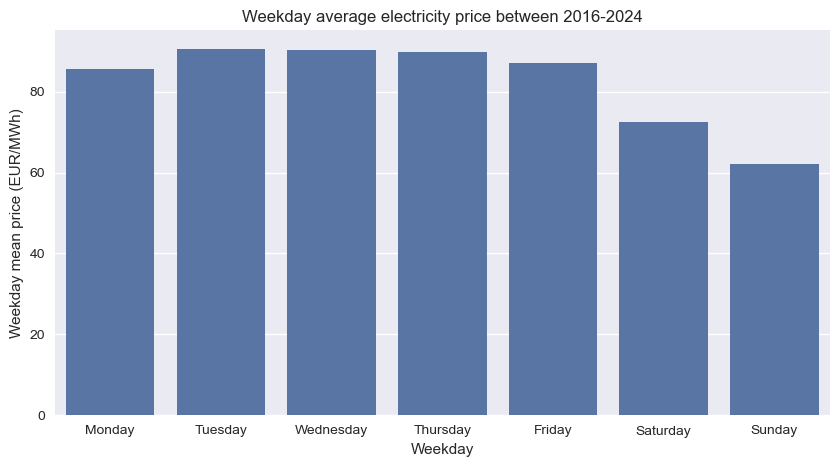

In [21]:
plt.figure(figsize = (10,5))
sns.barplot(data = weekday_mean, x = "weekday", y = "day_mean")
plt.xlabel("Weekday")
plt.ylabel("Weekday mean price (EUR/MWh)")
plt.title("Weekday average electricity price between 2016-2024")
plt.show()

Prices are generally lower on weekends, reflecting reduced industrial activity. The price mean on weekdays is 89 EUR/MWh while on weekends the price mean drops to 67 EUR/MWh. This pattern directly explains why negative prices concentrate on Sundays, as analysed in notebook 04.

### Seasonal Patterns

In [25]:
monthly_mean = df_alls.groupby(df_alls.index.month)["Day-ahead Price (EUR/MWh)"].agg(
    monthly_mean = "mean"
).reset_index().rename(columns = {"timestamp": "month"})

month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}
monthly_mean["month"] = monthly_mean["month"].map(month_map)
monthly_mean

,month,monthly_mean
0,Jan,80.590414
1,Feb,70.701395
2,Mar,75.494561
3,Apr,64.020304
4,May,55.824885
5,Jun,67.653202
6,Jul,87.905281
7,Aug,100.608672
8,Sep,98.825407
9,Oct,82.730294


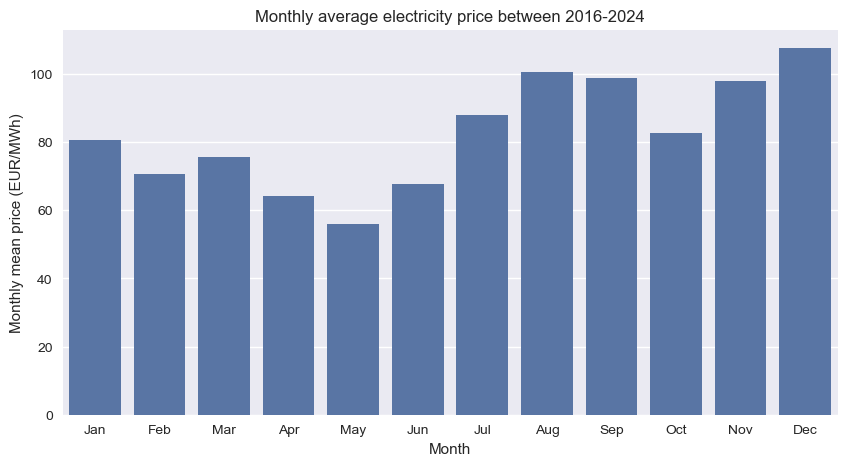

In [26]:
plt.figure(figsize = (10, 5))
sns.barplot(data = monthly_mean, x = "month", y ="monthly_mean")
plt.xlabel("Month")
plt.ylabel("Monthly mean price (EUR/MWh)")
plt.title("Monthly average electricity price between 2016-2024")
plt.show()

Winter months exhibit significantly higher prices (~30–40% higher), likely driven by heating demand and lower solar production.

### Yearly Patterns

In [27]:
yearly_mean = df_alls.groupby(df_alls.index.year)["Day-ahead Price (EUR/MWh)"].agg(
    yearly_mean = "mean"
).reset_index().rename(columns = {"timestamp": "year"})
yearly_mean

,year,yearly_mean
0,2016,36.748941
1,2017,44.965311
2,2018,50.198485
3,2019,39.449507
4,2020,32.203133
5,2021,109.171356
6,2022,275.878425
7,2023,96.855878
8,2024,58.018068


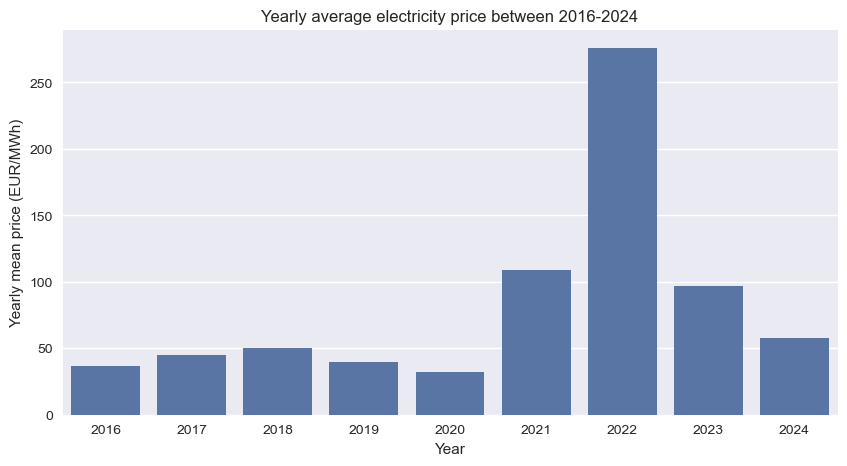

In [28]:
plt.figure(figsize = (10,5))
sns.barplot(yearly_mean, x = "year", y = "yearly_mean")
plt.xlabel("Year")
plt.ylabel("Yearly mean price (EUR/MWh)")
plt.title("Yearly average electricity price between 2016-2024")
plt.show()

A strong structural shift is visible across years:

- 2020 shows a dip in average prices, likely linked to reduced economic activity during COVID.
- 2021 marks a strong rebound.
- 2022 exhibits an extreme surge, with average prices more than 2.5× higher than in 2021.
- 2023 returns closer to historical norms.
- 2024 shows a further decline.

The magnitude of the 2022 increase indicates a structural market disruption rather than normal cyclical variation. The normalization in 2023–2024 suggests partial market stabilization.

## Summary

Temporal price patterns (hourly, weekly, montly) together describe a demand-driven price structure of electricity in France. But the yearly pattern breaks the logic in 2022 due to supply shock crisis. 